# Загрузка данных

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import chi2_contingency


In [2]:
df = pd.read_csv('data/mushrooms.csv').replace('?', np.nan)


In [3]:
df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
print(f'Датасет содержит {df.shape[0]} строк')
print(f'Датасет содержит {df.shape[1]} стролбцов')

Датасет содержит 8124 строк
Датасет содержит 23 стролбцов


In [5]:
print(df.columns.to_list())

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [7]:
TEST_SIZE = 0.2
RANDOM_STATE = 42
TARGET = 'class'

X = df.drop(columns=TARGET)
y = df[TARGET].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train: {X_train.shape}, test: {X_test.shape}')

Train: (6499, 22), test: (1625, 22)


# EDA 

## Проверка на дубликаты и пропуски

Все признаки категориальные, поэтому масштабирование не требуется. На этом шаге проверяем качество полного исходного датасета: дубликаты, пропуски и характеристики значений признаков.

In [8]:
print(f'Датасет содержит {df.duplicated().sum()} дубликатов')
print(f'Датасет содержит {df.isnull().sum().sum()} NaN значений')

Датасет содержит 0 дубликатов
Датасет содержит 2480 NaN значений


## Баланс классов 


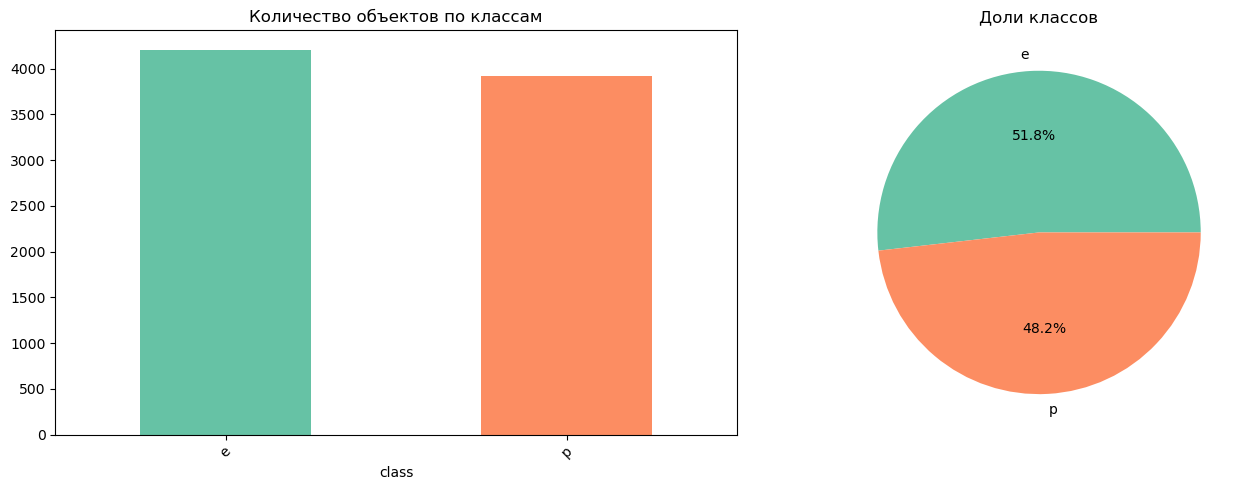

In [9]:
target_col = 'class'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

In [10]:
df.isnull().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [11]:
feature_columns = df.drop(columns=TARGET)

feature_summary = pd.DataFrame({
    'unique_values': feature_columns.nunique(),
    'missing_count': feature_columns.isna().sum(),
    'missing_share': round(feature_columns.isna().mean(),2)
}).sort_values('missing_count', ascending=False)

display(feature_summary)

constant_features = feature_summary.query('unique_values == 1').index.tolist()
print(f'Константные признаки: {constant_features}')

,unique_values,missing_count,missing_share
stalk-root,4,2480,0.31
cap-shape,6,0,0.00
stalk-surface-below-ring,4,0,0.00
population,6,0,0.00
spore-print-color,9,0,0.00
ring-type,5,0,0.00
ring-number,3,0,0.00
veil-color,4,0,0.00
veil-type,1,0,0.00
stalk-color-below-ring,9,0,0.00


Константные признаки: ['veil-type']


## Вывод по характеристикам признаков

Все входные признаки категориальные, поэтому масштабирование не требуется. Признак `veil-type` имеет только одно уникальное значение. Он не разделяет классы и не добавляет информации для классификации, поэтому перед обучением моделей будет удалён.

## План обработки пропусков

Пропуски встречаются в `stalk-root`. Будут сравнены три подхода:

1. удалить строки с пропуском;
2. заменить пропуск самой частой категорией;
3. заменить пропуск новой категорией `missing_value`.

Подходы сравним по F1 на кросс-валидации на `X_train` и `y_train`. 

## Анализ признаков ножки гриба

К признакам ножки относятся форма, корень, поверхность и цвет выше и ниже кольца. Для каждого признака посмотрим число категорий, долю пропусков и распределение классов внутри категорий. Визуальный анализ покажет, содержат ли эти признаки полезный сигнал; окончательная проверка гипотезы H2 будет выполнена моделью только на признаках ножки.

In [12]:
stalk_features = [
    'stalk-shape',
    'stalk-root',
    'stalk-surface-above-ring',
    'stalk-surface-below-ring',
    'stalk-color-above-ring',
    'stalk-color-below-ring'
]

print('Признаки ножки:', stalk_features)
display(feature_summary.loc[stalk_features])

Признаки ножки: ['stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring']


,unique_values,missing_count,missing_share
stalk-shape,2,0,0.00
stalk-root,4,2480,0.31
stalk-surface-above-ring,4,0,0.00
stalk-surface-below-ring,4,0,0.00
stalk-color-above-ring,9,0,0.00
stalk-color-below-ring,9,0,0.00


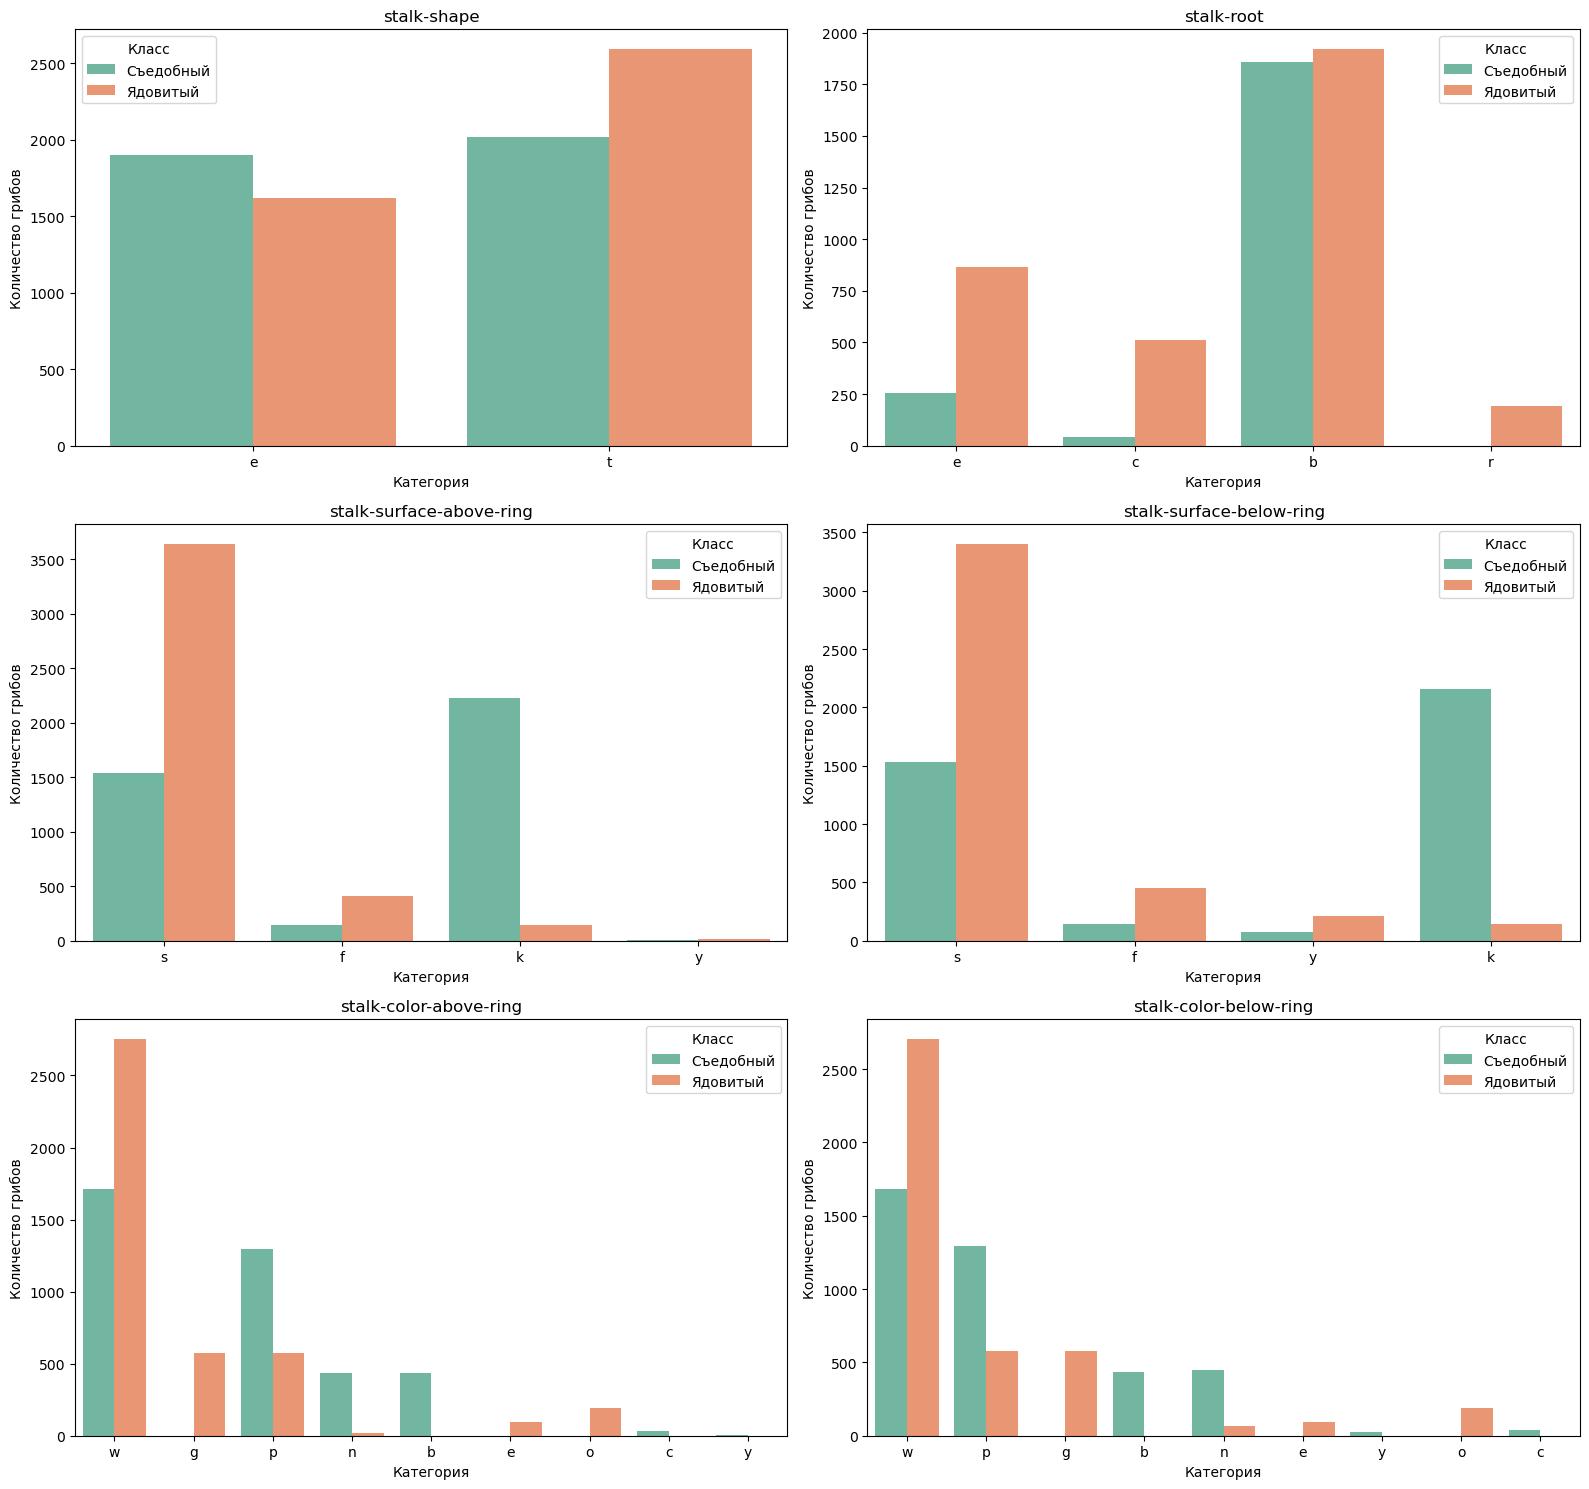

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for ax, feature in zip(axes.flat, stalk_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=TARGET,
        palette=['#66c2a5', '#fc8d62'],
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel('Категория')
    ax.set_ylabel('Количество грибов')
    ax.legend(['Съедобный', 'Ядовитый'], title='Класс')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Связь признаков с целевой переменной

Для категориальных признаков вместо корреляции Пирсона используем коэффициент Cramér's V. Он принимает значения от 0 до 1 и показывает силу связи отдельного признака с классом гриба. 

In [14]:
def cramers_v(first_feature, second_feature):
    first_feature = first_feature.replace('?', 'missing_value').fillna('missing_value')
    second_feature = second_feature.fillna('missing_value')

    contingency_table = pd.crosstab(first_feature, second_feature)

    if min(contingency_table.shape) <= 1:
        return 0.0

    chi_squared = chi2_contingency(
        contingency_table,
        correction=False
    )[0]

    n_objects = contingency_table.to_numpy().sum()
    n_rows, n_columns = contingency_table.shape
    phi_squared = chi_squared / n_objects

    corrected_phi_squared = max(
        0.0,
        phi_squared - (n_columns - 1) * (n_rows - 1) / (n_objects - 1)
    )

    corrected_rows = n_rows - (n_rows - 1) ** 2 / (n_objects - 1)
    corrected_columns = n_columns - (n_columns - 1) ** 2 / (n_objects - 1)
    denominator = min(corrected_rows - 1, corrected_columns - 1)

    return 0.0 if denominator <= 0 else np.sqrt(corrected_phi_squared / denominator)

,cramers_v
odor,0.970148
spore-print-color,0.755038
gill-color,0.679044
ring-type,0.603549
stalk-surface-above-ring,0.591432
stalk-surface-below-ring,0.575920
gill-size,0.532388
stalk-color-above-ring,0.525743
stalk-color-below-ring,0.516947
bruises,0.502508


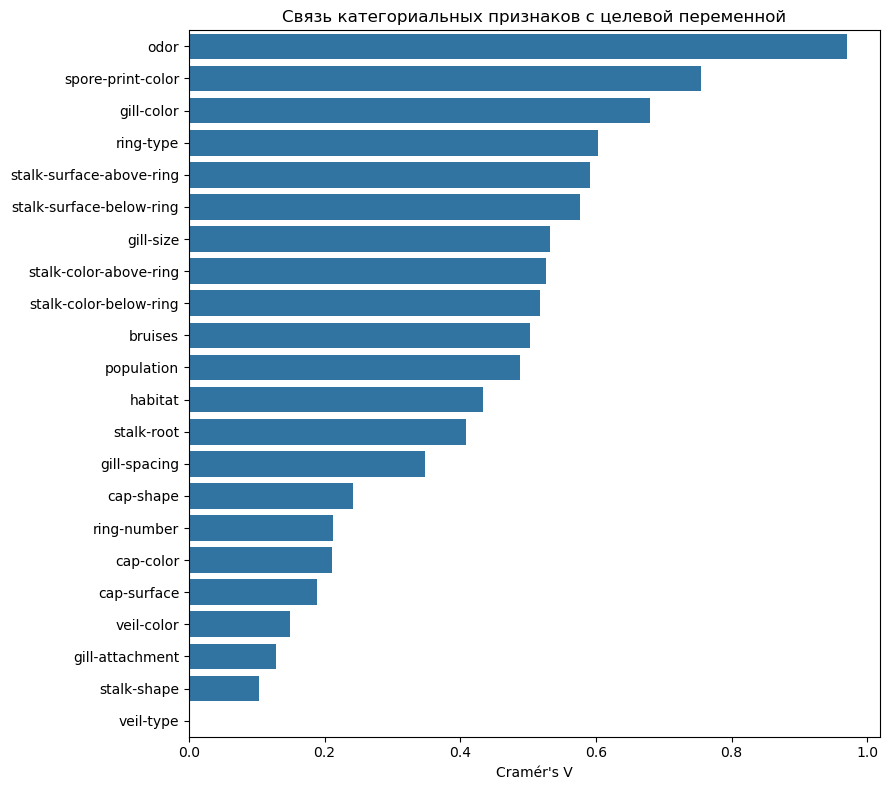

In [15]:
target_associations = pd.Series({
    feature: cramers_v(X_train[feature], y_train)
    for feature in X_train.columns
}, name='cramers_v').sort_values(ascending=False)

display(target_associations.to_frame())

plt.figure(figsize=(9, 8))
sns.barplot(
    x=target_associations.values,
    y=target_associations.index
)
plt.title("Связь категориальных признаков с целевой переменной")
plt.xlabel("Cramér's V")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Матрица связей между признаками

Heatmap показывает попарные связи Cramér's V между категориальными признаками.

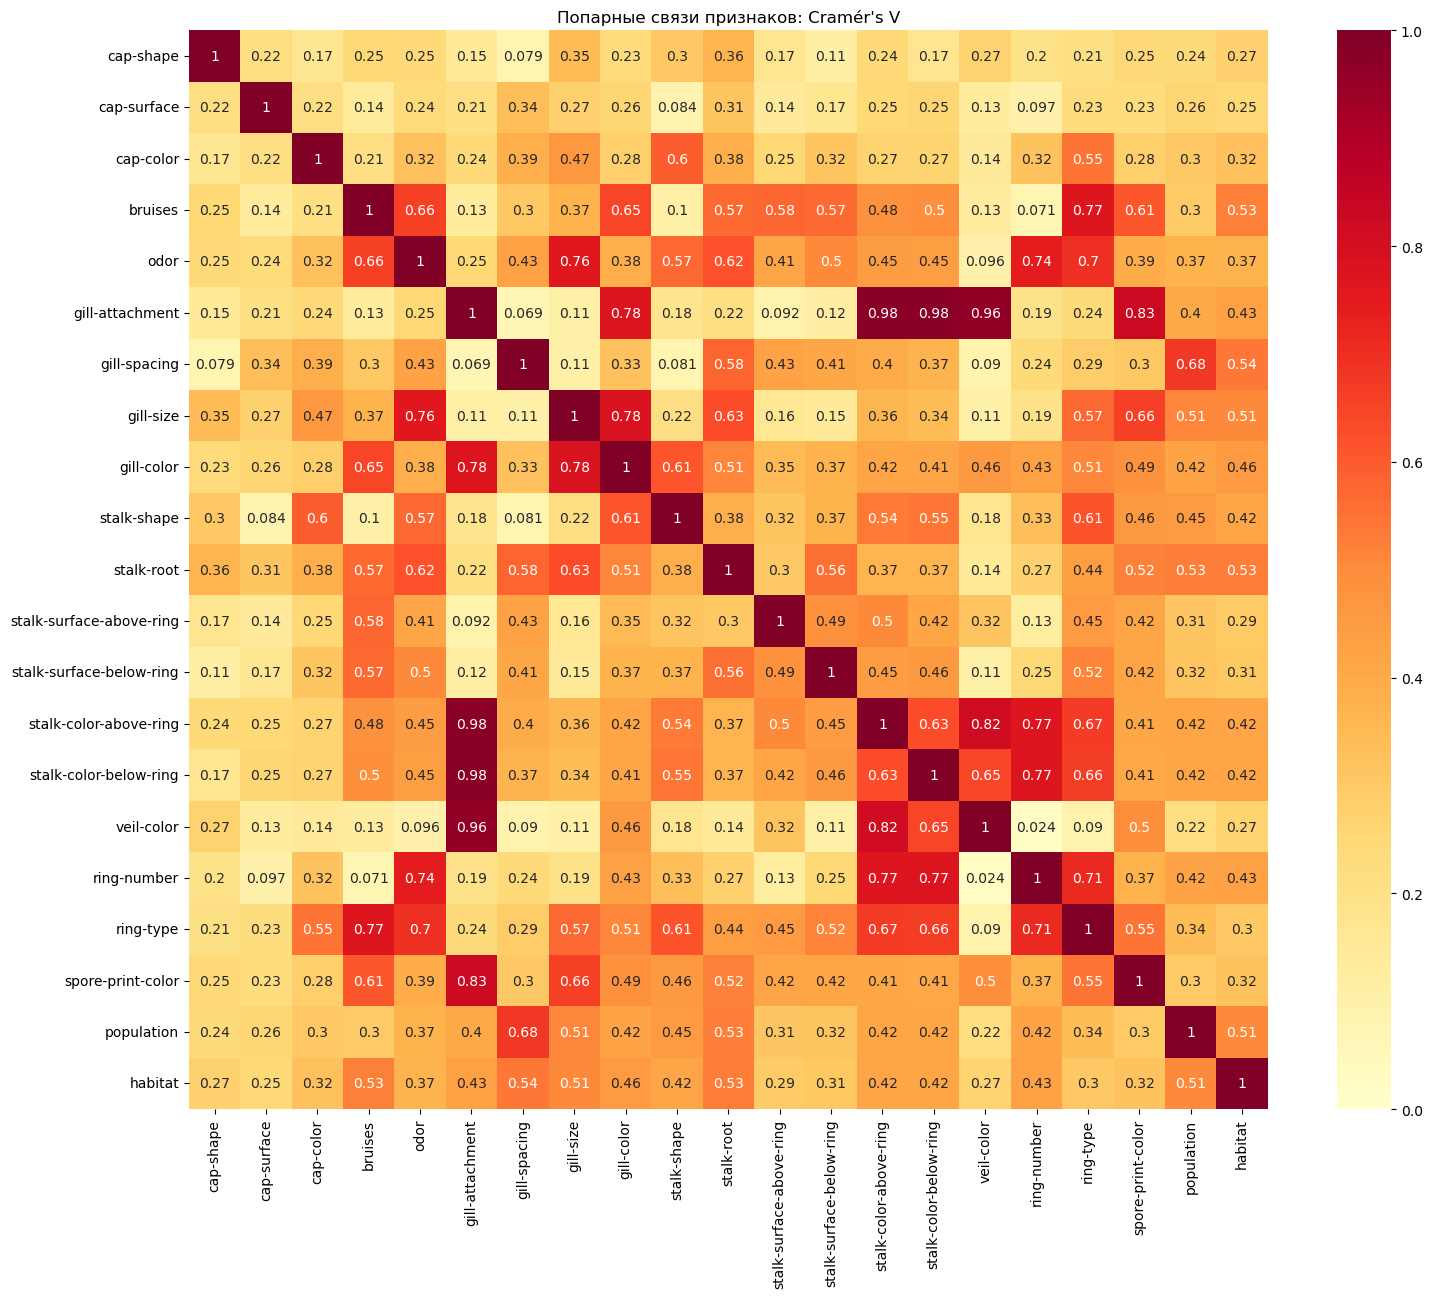

In [16]:
heatmap_features = [
    feature for feature in X_train.columns
    if feature != 'veil-type'
]

association_matrix = pd.DataFrame(
    np.eye(len(heatmap_features)),
    index=heatmap_features,
    columns=heatmap_features
)

for index, first_feature in enumerate(heatmap_features):
    for second_feature in heatmap_features[index + 1:]:
        association = cramers_v(
            X_train[first_feature],
            X_train[second_feature]
        )
        association_matrix.loc[first_feature, second_feature] = association
        association_matrix.loc[second_feature, first_feature] = association

plt.figure(figsize=(16, 13))
sns.heatmap(
    association_matrix,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    square=True,
    annot = True
)
plt.title("Попарные связи признаков: Cramér's V")
plt.tight_layout()
plt.show()

## Итоги EDA

1. Датасет содержит 8124 объектов, 22 входных признака и один целевой столбец `class`. Все входные признаки категориальные, поэтому масштабирование не требуется.

2. Дубликатов не найдено. Пропуски обозначены символом `?` и встречаются только в `stalk-root`: 2480 значений, или около 31% датасета.

3. Классы близки к сбалансированным: примерно 51.8% грибов съедобные и 48.2% ядовитые. Это предварительно поддерживает H1; окончательно её проверим после сравнения accuracy и F1 у моделей.

4. `veil-type` является константным признаком и не несёт информации для классификации, поэтому будет исключён.

5. Наиболее сильную индивидуальную связь с целевой переменной показывают `odor` 0.97, `spore-print-color` 0.76, `gill-color` 0.68 и `ring-type` 0.60. Среди признаков ножки наиболее связаны с классом поверхности ножки выше 0.59 и ниже кольца 0.58.

6. `bruises` имеет  связь с классом  = 0.50 , но его важность и попадание в top-5 должны быть проверены после обучения модели.


# Подготовка данных 


In [17]:
MODEL_FEATURES = [feature for feature in X_train.columns if feature != 'veil-type']
X_train_model = X_train[MODEL_FEATURES].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

def make_pipeline(model, fill_value=None):
    imputer = SimpleImputer(
        strategy='most_frequent' if fill_value is None else 'constant',
        fill_value=fill_value,
    )

    return Pipeline(steps=[
        ('imputer', imputer),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('model', model),
    ])


def evaluate(name, estimator, X, y):
    scores = cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        error_score='raise',
    )

    return {
        'strategy': name,
        **{
            f'{metric}_mean': scores[f'test_{metric}'].mean()
            for metric in SCORING
        },
    }



## Сравнение стратегий обработки пропусков

Во всех экспериментах используются одинаковые Logistic Regression, one-hot кодирование, стратифицированная 5-fold кросс-валидация и метрики. Поэтому различия в результатах отражают только способ обработки пропусков в `stalk-root`.


In [18]:
drop_mask = X_train_model['stalk-root'].notna()

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

most_frequent_pipeline = make_pipeline(log_reg)

missing_value_pipeline = make_pipeline(
    log_reg,
    fill_value='missing_value',
)

no_missing_pipeline = make_pipeline(log_reg)

strategy_results = [
    evaluate(
        'Удаление строк',
        no_missing_pipeline,
        X_train_model.loc[drop_mask],
        y_train.loc[drop_mask],
    ),
    evaluate(
        'Самая частая категория',
        most_frequent_pipeline,
        X_train_model,
        y_train,
    ),
    evaluate(
        'Отдельная категория missing_value',
        missing_value_pipeline,
        X_train_model,
        y_train,
    ),
]

preprocessing_results = (
    pd.DataFrame(strategy_results)
    .sort_values('f1_mean', ascending=False)
    .reset_index(drop=True)
)

display(preprocessing_results.round(4))


,strategy,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Самая частая категория,0.9994,1.0,0.9987,0.9994,1.0
1,Отдельная категория missing_value,0.9994,1.0,0.9987,0.9994,1.0
2,Удаление строк,0.9991,1.0,0.9977,0.9988,1.0


In [19]:
best_f1 = preprocessing_results['f1_mean'].max()
best_strategies = preprocessing_results.loc[
    np.isclose(preprocessing_results['f1_mean'], best_f1),
    'strategy',
].tolist()

selected_strategy = 'Самая частая категория'
selected_result = preprocessing_results.query(
    'strategy == @selected_strategy'
).iloc[0]

print(
    f"Максимальный средний F1 ({best_f1:.4f}) показали: "
    f"{', '.join(best_strategies)}.\n"
    f"Для дальнейшего моделирования выбрана стратегия "
    f"«{selected_strategy}»: она проще в интерпретации."
)


Максимальный средний F1 (0.9994) показали: Самая частая категория, Отдельная категория missing_value.
Для дальнейшего моделирования выбрана стратегия «Самая частая категория»: она проще в интерпретации.


# Моделирование и проверка гипотез

Во всех экспериментах применяются выбранная обработка пропусков (наиболее частая категория), one-hot кодирование, одинаковая 5-fold кросс-валидация и одни метрики. Поэтому сравнения отражают влияние набора признаков или модели.


## Logistic Regression: сравнение наборов признаков

Сравниваем LogReg на признаках ножки, всех признаках и только на `bruises`.


In [20]:
stalk_features = [
    'stalk-shape',
    'stalk-root',
    'stalk-surface-above-ring',
    'stalk-surface-below-ring',
    'stalk-color-above-ring',
    'stalk-color-below-ring',
]

logreg_pipeline = make_pipeline(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

logreg_feature_results = pd.DataFrame([
    evaluate(
        'LogReg: признаки ножки',
        logreg_pipeline,
        X_train_model[stalk_features],
        y_train,
    ),
    evaluate(
        'LogReg: все признаки',
        logreg_pipeline,
        X_train_model,
        y_train,
    ),
    evaluate(
        'LogReg: только bruises',
        logreg_pipeline,
        X_train_model[['bruises']],
        y_train,
    ),
]).sort_values('f1_mean', ascending=False).reset_index(drop=True)

display(logreg_feature_results.round(4))


,strategy,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,LogReg: все признаки,0.9994,1.000,0.9987,0.9994,1.0000
1,LogReg: признаки ножки,0.8074,0.844,0.7408,0.7876,0.9193
2,LogReg: только bruises,0.7446,0.694,0.8407,0.7604,0.7479


## Decision Tree: сравнение глубины

Сравниваем неглубокое дерево (`max_depth=5`) и неограниченное дерево.


In [21]:
tree_depth_results = pd.DataFrame([
    evaluate(
        'Decision Tree: max_depth=5',
        make_pipeline(DecisionTreeClassifier(
            max_depth=5,
            random_state=RANDOM_STATE,
        )),
        X_train_model,
        y_train,
    ),
    evaluate(
        'Decision Tree: max_depth=None',
        make_pipeline(DecisionTreeClassifier(
            max_depth=None,
            random_state=RANDOM_STATE,
        )),
        X_train_model,
        y_train,
    ),
]).sort_values('f1_mean', ascending=False).reset_index(drop=True)

display(tree_depth_results.round(4))


,strategy,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Decision Tree: max_depth=5,0.9997,1.0,0.9994,0.9997,0.9997
1,Decision Tree: max_depth=None,0.9997,1.0,0.9994,0.9997,0.9997


## Подбор гиперпараметров и выбор модели

Для обеих моделей параметры выбираются по среднему F1 на кросс-валидации.


In [22]:
searches = {
    'Logistic Regression': GridSearchCV(
        estimator=make_pipeline(LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
        param_grid={'model__C': [0.01, 0.1, 1, 10, 100]},
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True,
    ),
    'Decision Tree': GridSearchCV(
        estimator=make_pipeline(DecisionTreeClassifier(
            random_state=RANDOM_STATE,
        )),
        param_grid={
            'model__max_depth': [3, 5, 10, None],
            'model__min_samples_split': [2, 10, 20],
            'model__min_samples_leaf': [1, 5, 10],
            'model__criterion': ['gini', 'entropy'],
        },
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True,
    ),
}

for search in searches.values():
    search.fit(X_train_model, y_train)

tuning_results = pd.DataFrame([
    {
        'model': name,
        'best_f1_cv': search.best_score_,
        'best_params': search.best_params_,
    }
    for name, search in searches.items()
]).sort_values('best_f1_cv', ascending=False).reset_index(drop=True)

best_model_name = tuning_results.loc[0, 'model']
best_search = searches[best_model_name]

display(tuning_results)


,model,best_f1_cv,best_params
0,Logistic Regression,1.000000,{'model__C': 100}
1,Decision Tree,0.999681,"{'model__criterion': 'gini', 'model__max_depth..."


## Отбор 15 лучших признаков

Для отбора используем уже рассчитанный на обучающей выборке Cramér's V. Затем сравниваем лучшую модель на всех и на 15 лучших признаках.


In [23]:
top_15_features = target_associations.head(15).index.tolist()

top_15_results = pd.DataFrame([
    evaluate(
        f'{best_model_name}: все признаки',
        best_search.best_estimator_,
        X_train_model,
        y_train,
    ),
    evaluate(
        f'{best_model_name}: top-15',
        best_search.best_estimator_,
        X_train_model[top_15_features],
        y_train,
    ),
]).sort_values('f1_mean', ascending=False).reset_index(drop=True)

print('Top-15 признаков:', top_15_features)
display(top_15_results.round(4))


Top-15 признаков: ['odor', 'spore-print-color', 'gill-color', 'ring-type', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'gill-size', 'stalk-color-above-ring', 'stalk-color-below-ring', 'bruises', 'population', 'habitat', 'stalk-root', 'gill-spacing', 'cap-shape']


,strategy,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Logistic Regression: все признаки,1.0,1.0,1.0,1.0,1.0
1,Logistic Regression: top-15,1.0,1.0,1.0,1.0,1.0


## Финальная оценка и важность признаков

Финальную выбранную модель обучаем на всех признаках обучающей выборки и один раз оцениваем на тестовой. Permutation importance измеряет вклад исходных признаков в F1.


In [24]:
from sklearn.base import clone

final_pipeline = clone(best_search.best_estimator_)
final_pipeline.fit(X_train_model, y_train)

X_test_model = X_test[MODEL_FEATURES]
y_test_pred = final_pipeline.predict(X_test_model)
y_test_proba = final_pipeline.predict_proba(X_test_model)[:, 1]

test_results = pd.DataFrame([{
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred, zero_division=0),
    'recall': recall_score(y_test, y_test_pred, zero_division=0),
    'f1': f1_score(y_test, y_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_test_proba),
}])

display(test_results.round(4))

importance = permutation_importance(
    final_pipeline,
    X_test_model,
    y_test,
    scoring='f1',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'importance_mean': importance.importances_mean,
    'importance_std': importance.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

bruises_rank = feature_importance.index[
    feature_importance['feature'].eq('bruises')
][0] + 1

display(feature_importance.head(15).round(4))
print(f'Ранг bruises: {bruises_rank}')


,accuracy,precision,recall,f1,roc_auc
0,1.0,1.0,1.0,1.0,1.0


,feature,importance_mean,importance_std
0,odor,0.1606,0.0072
1,gill-size,0.0516,0.0038
2,gill-spacing,0.0117,0.0012
3,spore-print-color,0.0076,0.0010
4,stalk-surface-above-ring,0.0054,0.0014
5,stalk-root,0.0017,0.0010
6,stalk-shape,0.0012,0.0006
7,population,0.0012,0.0005
8,habitat,0.0011,0.0004
9,gill-color,0.0009,0.0006


Ранг bruises: 20


## Итоги моделирования

Выводы ниже формируются из фактических результатов экспериментов без заранее заданных порогов.


In [25]:
stalk_f1 = logreg_feature_results.loc[
    logreg_feature_results['strategy'].eq('LogReg: признаки ножки'),
    'f1_mean',
].iloc[0]
bruises_f1 = logreg_feature_results.loc[
    logreg_feature_results['strategy'].eq('LogReg: только bruises'),
    'f1_mean',
].iloc[0]
tree_f1_gap = abs(
    tree_depth_results.loc[0, 'f1_mean']
    - tree_depth_results.loc[1, 'f1_mean']
)
top_15_f1_gap = abs(
    top_15_results.loc[0, 'f1_mean']
    - top_15_results.loc[1, 'f1_mean']
)

print(f'H2: F1 LogReg на признаках ножки = {stalk_f1:.4f}.')
print(f'Отдельный признак bruises: F1 = {bruises_f1:.4f}.')
print(f'H3: разница F1 двух деревьев = {tree_f1_gap:.4f}.')
print(f'H5: разница F1 всех признаков и top-15 = {top_15_f1_gap:.4f}.')
print(
    f'H1: accuracy финальной модели = {test_results.loc[0, "accuracy"]:.4f}; '
    f'F1 = {test_results.loc[0, "f1"]:.4f}.'
)
print(f'H4: ранг bruises по permutation importance = {bruises_rank}.')


H2: F1 LogReg на признаках ножки = 0.7876.
Отдельный признак bruises: F1 = 0.7604.
H3: разница F1 двух деревьев = 0.0000.
H5: разница F1 всех признаков и top-15 = 0.0000.
H1: accuracy финальной модели = 1.0000; F1 = 1.0000.
H4: ранг bruises по permutation importance = 20.


## Матрица ошибок

Матрица ошибок показывает число правильных и ошибочных предсказаний финальной модели на тестовой выборке.


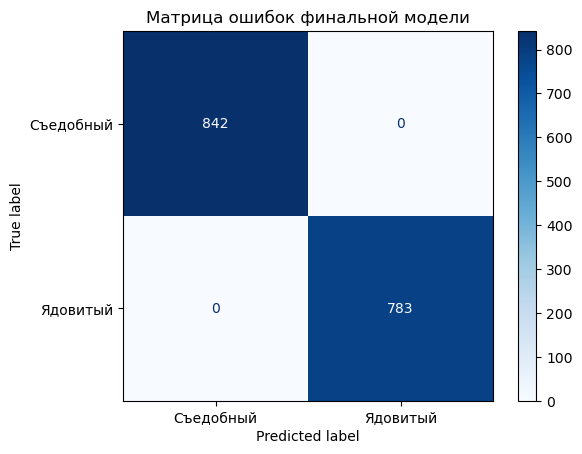

In [26]:
confusion = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=['Съедобный', 'Ядовитый'],
)

confusion_display.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок финальной модели')
plt.show()


## Выводы по гипотезам

1. **H1. Баланс классов.** У финальной модели accuracy и F1 на тестовой выборке равны `1.0000`. Это согласуется с выводом EDA о близком балансе классов: качество для класса ядовитых грибов не ухудшается относительно общей accuracy.

2. **H2. Признаки ножки.** LogReg только на признаках ножки достигла F1 `0.7876`, тогда как на всех признаках — `0.9994`. Признаки ножки содержат полезный сигнал, но не заменяют полный набор признаков.

3. **H3. Неглубокое дерево.** Деревья с `max_depth=5` и без ограничения глубины показали одинаковый средний F1 `0.9997`. Для этих данных сложное глубокое дерево не даёт преимущества.

4. **H4. Признак `bruises`.** Модель только на `bruises` получила F1 `0.7604`, то есть признак информативен сам по себе. Однако в permutation importance финальной модели он занимает только 20-е место.

5. **H5. Top-15 признаков.** Лучшая модель показала F1 `1.0000` и на всех признаках, и на 15 признаках с наибольшим Cramér's V. Следовательно, для этого эксперимента top-15 признаков достаточно.
